In [127]:
#import statments
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.stats import norm


In [128]:
#Black - Scholes prices

S0 = 100
K = 100
T = 1
r = 0.03
sd = 0.20

d1 = (np.log(S0/K) + (r + 0.5 * sd**2) * T) / (sd * np.sqrt(T))
d2 = round(d1 - sd*np.sqrt(T),3)

V_BS = S0 * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)
print("Black-Scholes price:", V_BS)

Black-Scholes price: 9.413403383853016


In [129]:
def monte_carlo(M):
    Z = np.random.normal(0,1,M)

    ST = S0 * np.exp((r - 0.5 * sd**2) * T + sd * np.sqrt(T) * Z)

    payoff = np.maximum(ST-K,0)
    
    price_est = np.exp(-r * T)*np.mean(payoff)

    sample_sd = np.std(payoff, ddof=1)
    sample_sd_error = np.exp(-r * T)*sample_sd/np.sqrt(M)
    confid_U = price_est + 1.96*sample_sd_error
    confid_L = price_est - 1.96*sample_sd_error
    confid = [float(confid_U), float(confid_L)]
    return price_est, confid



In [ ]:
#convergence study
M_list = [10**2, 5*10**2, 10**3, 5*10**3, 10**4, 5*10**4, 10**5,5*10**5]
R = 100
RMSE_list = []
Vm_one = []

all_CI_l= []
all_CI_u = []
all_Vm = []

coverage_list = []

for M in M_list:

    Vm_list = np.array([])
    CI_l_list = np.array([])
    CI_u_list = np.array([])

    for x in range(R):

        Vm, con = monte_carlo(M)
        Vm_list= np.append(Vm_list, Vm)

        CI_u_list = np.append(CI_u_list, con[0])
        CI_l_list = np.append(CI_l_list, con[1])
        

    Vm_one.append(Vm_list[0])

    RMSE = np.sqrt(np.mean((Vm_list-V_BS)**2))
    RMSE_list.append(float(RMSE))


    all_Vm.append(Vm_list)
    all_CI_l.append(CI_l_list)
    all_CI_u.append(CI_u_list)

    #if interval set True
    covered = (CI_l_list <= V_BS) & (V_BS <= CI_u_list)
    coverage = np.mean(covered) #percentage for M. over all R

    coverage_list.append(coverage)

    


[1.3347239380913847, 0.6554294889100897, 0.5083979120592947, 0.19627076778740288, 0.13952300616596497, 0.06354632567746743, 0.04548708233526426, 0.02042673398841621]


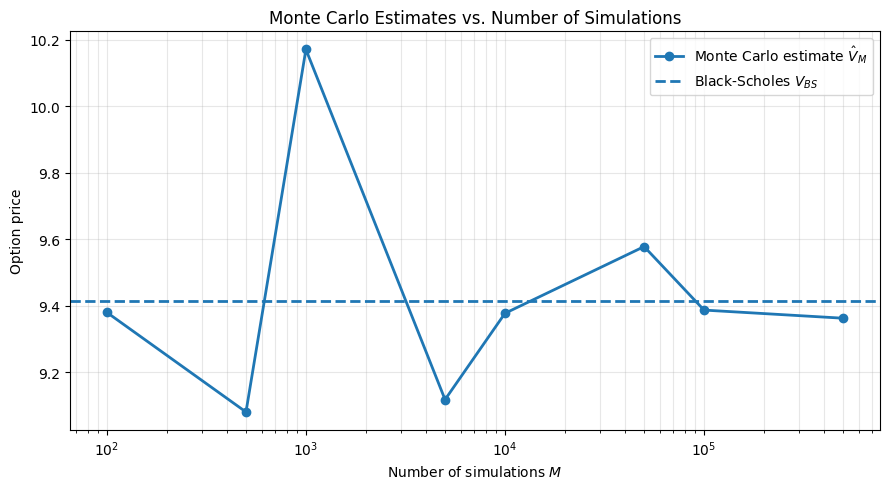

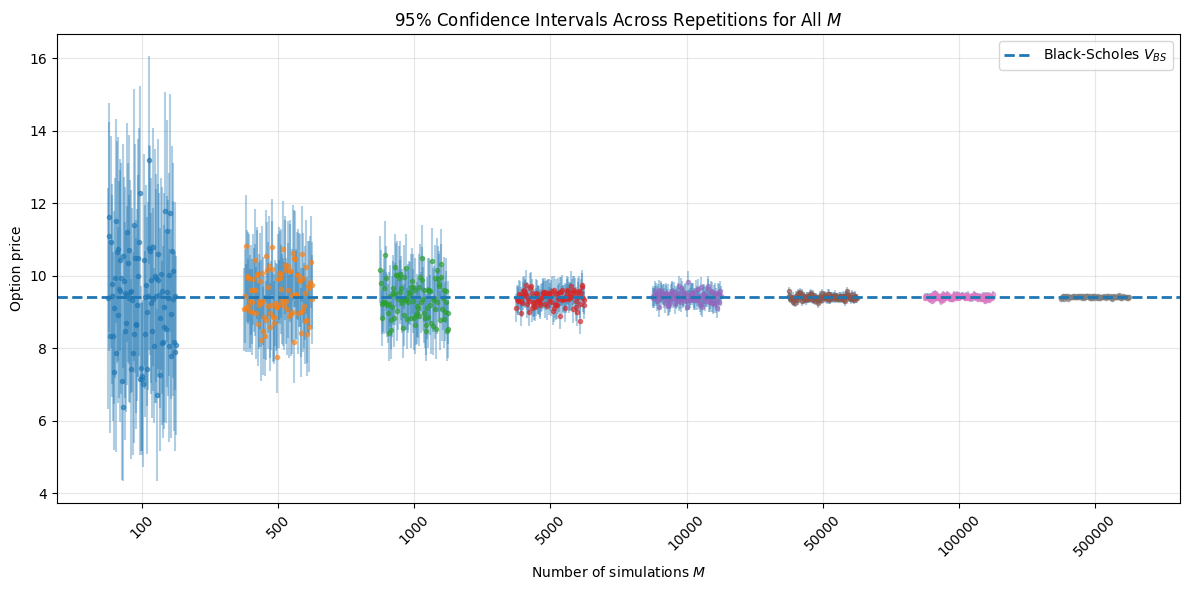

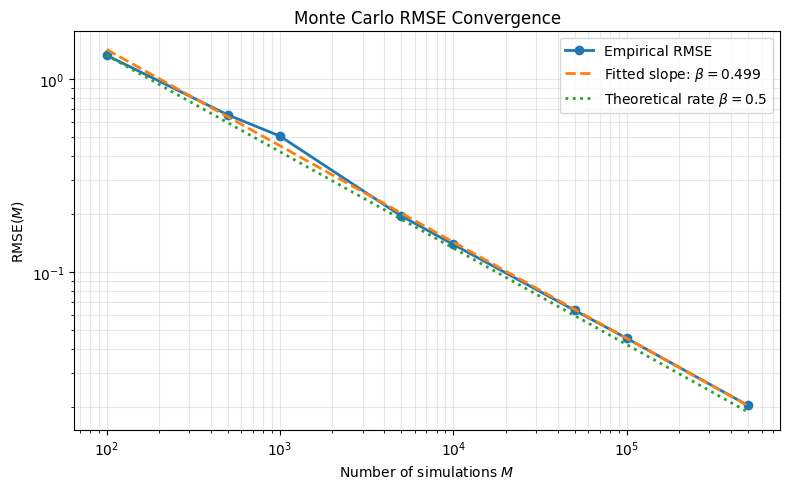

Estimated beta: 0.4991920973744722
Theoretical beta: 0.5


In [131]:
#plots
plt.figure(figsize=(9, 5))

# Representative Monte Carlo estimates
plt.plot(
    M_list,
    Vm_one,
    marker="o",
    linewidth=2,
    markersize=6,
    label=r"Monte Carlo estimate $\hat{V}_M$"
)


plt.axhline(
    y=V_BS,
    linestyle="--",
    linewidth=2,
    label=r"Black-Scholes $V_{BS}$"
)

plt.xscale("log")

plt.xlabel("Number of simulations $M$")
plt.ylabel("Option price")
plt.title("Monte Carlo Estimates vs. Number of Simulations")

plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()


#plots for coverage and confidence interval
plt.figure(figsize=(12, 6))

for i, M in enumerate(M_list):
    Vm_vals = all_Vm[i]
    CI_l_vals = all_CI_l[i]
    CI_u_vals = all_CI_u[i]

    R = len(Vm_vals)

    # spread repetitions slightly around each M-position
    x_positions = np.linspace(i - 0.25, i + 0.25, R)

    # vertical confidence intervals
    plt.vlines(x_positions, CI_l_vals, CI_u_vals, alpha=0.35)

    # point estimates
    plt.plot(x_positions, Vm_vals, 'o', markersize=3, alpha=0.6)

plt.axhline(V_BS, linestyle='--', linewidth=2, label=r'Black-Scholes $V_{BS}$')

plt.xticks(range(len(M_list)), [str(M) for M in M_list], rotation=45)
plt.xlabel("Number of simulations $M$")
plt.ylabel("Option price")
plt.title("95% Confidence Intervals Across Repetitions for All $M$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

#plot for rmse against M

M_array = np.array(M_list)
RMSE_array = np.array(RMSE_list)


log_M = np.log(M_array)
log_RMSE = np.log(RMSE_array)


slope, a = np.polyfit(log_M, log_RMSE, 1)


beta_est = -slope


RMSE_fit = np.exp(a) * M_array**(-beta_est)

theoretical_line = RMSE_array[0] * (M_array / M_array[0])**(-0.5)

# Plot
plt.figure(figsize=(8, 5))

plt.loglog(
    M_array,
    RMSE_array,
    marker="o",
    linewidth=2,
    markersize=6,
    label="Empirical RMSE"
)

plt.loglog(
    M_array,
    RMSE_fit,
    linestyle="--",
    linewidth=2,
    label=fr"Fitted slope: $\beta={beta_est:.3f}$"
)

plt.loglog(
    M_array,
    theoretical_line,
    linestyle=":",
    linewidth=2,
    label=r"Theoretical rate $\beta=0.5$"
)

plt.xlabel("Number of simulations $M$")
plt.ylabel("RMSE$(M)$")
plt.title("Monte Carlo RMSE Convergence")

plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

print("Estimated beta:", beta_est)
print("Theoretical beta:", 0.5)

